In [54]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import mplhep as hep
from pathlib import Path
import scipy
import os
import sys
from matplotlib.patches import Patch

hep.style.use(hep.style.CMS)

In [101]:
COLUMNS = [
    "epoch",
    "decorr_lambda",
    "cat1_corr",
    "cat1_corr_uncert",
    "cat1_corr_min",
    "cat1_corr_max",
    "cat2_corr",
    "cat2_corr_uncert",
    "cat2_corr_min",
    "cat2_corr_max",
    "cat3_corr",
    "cat3_corr_uncert",
    "cat3_corr_min",
    "cat3_corr_max",
    "cat1_Z",
    "cat2_Z",
    "cat3_Z",
    "cat1_z_sum_quad",
    "cat2_z_sum_quad",
    "cat3_z_sum_quad",
]



In [103]:
def load_categorization_results(decorr_lambda: float, base_path: Path|str, verbose: bool = False) -> pd.DataFrame:
    if isinstance(base_path, str):
        base_path = Path(base_path)
    pattern = f"optuna_categorization/epoch*"
    epoch_dirs = list(base_path.glob(pattern))
    if len(epoch_dirs) == 0:
        raise FileNotFoundError(f"No epoch directories found with pattern '{pattern}' in {base_path}.")
    epochs_path: dict[int, Path] = {}
    for epoch_dir in epoch_dirs:
        epoch_str = epoch_dir.name.replace("epoch", "")
        if epoch_str.isdigit():
            epoch = int(epoch_str)
            epochs_path[epoch] = epoch_dir
    epochs_path = dict(sorted(epochs_path.items()))
    if verbose:
        for e, p in epochs_path.items():
            print(f"Found epoch {e} at path: {p}")

    df = pd.DataFrame(columns=COLUMNS)
    for epoch, path in epochs_path.items():
        categorization_file = path / "category_summary_data.csv"
        if not categorization_file.exists():
            print(f"Warning: Categorization file not found at {categorization_file}, skipping.")
            continue
        df_epoch = pd.read_csv(categorization_file)
        row = {
            "epoch": epoch,
            "decorr_lambda": decorr_lambda,
            "cat1_corr": df_epoch.at[0, "weighted_pearson_corr_mean"],
            "cat1_corr_uncert": df_epoch.at[0, "weighted_pearson_corr_std"],
            "cat1_corr_min": df_epoch.at[0, "weighted_pearson_corr_min"],
            "cat1_corr_max": df_epoch.at[0, "weighted_pearson_corr_max"],
            "cat2_corr": df_epoch.at[1, "weighted_pearson_corr_mean"],
            "cat2_corr_uncert": df_epoch.at[1, "weighted_pearson_corr_std"],
            "cat2_corr_min": df_epoch.at[1, "weighted_pearson_corr_min"],
            "cat2_corr_max": df_epoch.at[1, "weighted_pearson_corr_max"],
            "cat3_corr": df_epoch.at[2, "weighted_pearson_corr_mean"],
            "cat3_corr_uncert": df_epoch.at[2, "weighted_pearson_corr_std"],
            "cat3_corr_min": df_epoch.at[2, "weighted_pearson_corr_min"],
            "cat3_corr_max": df_epoch.at[2, "weighted_pearson_corr_max"],
            "cat1_Z": df_epoch.at[0, "z_score"],
            "cat2_Z": df_epoch.at[1, "z_score"],
            "cat3_Z": df_epoch.at[2, "z_score"],
            "cat1_z_sum_quad": df_epoch.at[0, "z_sum_quadrature"],
            "cat2_z_sum_quad": df_epoch.at[1, "z_sum_quadrature"],
            "cat3_z_sum_quad": df_epoch.at[2, "z_sum_quadrature"],
        }
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    return df

# df = load_categorization_results(Path("../Version_20250524_MVAID_forPreApp/.sculpting_300epochs_0.00DisCo-SigUpweight-nonResmask-MggMjj-1.0min1000max-thresholds0.5HH0.1nonRes"), 0.0)
df = load_categorization_results(0.0, Path("../Version_20250524_MVAID_forPreApp/"))
df.head()


/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_64040/3527124809.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)


,epoch,decorr_lambda,cat1_corr,cat1_corr_uncert,cat1_corr_min,cat1_corr_max,cat2_corr,cat2_corr_uncert,cat2_corr_min,cat2_corr_max,cat3_corr,cat3_corr_uncert,cat3_corr_min,cat3_corr_max,cat1_Z,cat2_Z,cat3_Z,cat1_z_sum_quad,cat2_z_sum_quad,cat3_z_sum_quad
0,0,0.0,-0.001825,0.023339,-0.054592,0.064184,0.489140,0.015087,0.446262,0.528408,-0.119591,0.015008,-0.160119,-0.078388,0.183983,0.074056,0.039875,0.183983,0.198328,0.202297
1,10,0.0,0.089001,0.023778,0.009365,0.151279,-0.177354,0.024646,-0.255239,-0.118703,0.100293,0.013876,0.058997,0.134429,0.210590,0.074116,0.037869,0.210590,0.223251,0.226440
2,20,0.0,0.040491,0.024339,-0.024526,0.095629,-0.026359,0.021496,-0.095954,0.026868,0.136807,0.015271,0.098589,0.171761,0.221994,0.077936,0.034318,0.221994,0.235277,0.237767
3,30,0.0,0.025503,0.025713,-0.044038,0.136668,-0.040945,0.026021,-0.106236,0.032359,0.083725,0.016692,0.033596,0.124697,0.222566,0.072258,0.037829,0.222566,0.234001,0.237039
4,40,0.0,0.259001,0.023252,0.198933,0.317511,-0.045469,0.018323,-0.096288,0.016603,0.203502,0.016514,0.166335,0.243779,0.226244,0.083880,0.031706,0.226244,0.241293,0.243367


/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_64040/511971931.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_64040/4088870060.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df_000], ignore_index=True)


,epoch,decorr_lambda,cat1_corr,cat1_corr_uncert,cat2_corr,cat2_corr_uncert,cat3_corr,cat3_corr_uncert,cat1_Z,cat2_Z,cat3_Z,cat1_corr_min,cat1_corr_max,cat2_corr_min,cat2_corr_max,cat3_corr_min,cat3_corr_max
0,0,0.0,-0.001825,0.023339,0.489140,0.015087,-0.119591,0.015008,0.183983,0.074056,0.039875,-0.054592,0.064184,0.446262,0.528408,-0.160119,-0.078388
1,10,0.0,0.089001,0.023778,-0.177354,0.024646,0.100293,0.013876,0.210590,0.074116,0.037869,0.009365,0.151279,-0.255239,-0.118703,0.058997,0.134429
2,20,0.0,0.040491,0.024339,-0.026359,0.021496,0.136807,0.015271,0.221994,0.077936,0.034318,-0.024526,0.095629,-0.095954,0.026868,0.098589,0.171761
3,30,0.0,0.025503,0.025713,-0.040945,0.026021,0.083725,0.016692,0.222566,0.072258,0.037829,-0.044038,0.136668,-0.106236,0.032359,0.033596,0.124697
4,40,0.0,0.259001,0.023252,-0.045469,0.018323,0.203502,0.016514,0.226244,0.083880,0.031706,0.198933,0.317511,-0.096288,0.016603,0.166335,0.243779
5,50,0.0,0.566974,0.050424,0.096391,0.019613,0.293376,0.015610,0.263281,0.145234,0.044532,0.377484,0.685320,0.037130,0.140074,0.250902,0.338915
6,60,0.0,0.468499,0.067515,0.299228,0.018623,0.204212,0.018897,0.276652,0.171667,0.062168,0.284916,0.658153,0.251208,0.364420,0.161991,0.262227
7,70,0.0,0.353067,0.047747,0.369647,0.015814,0.141477,0.017460,0.332963,0.133385,0.054389,0.220930,0.453859,0.321456,0.413526,0.101801,0.183356


In [ ]:
# # decorr_lambda = 0.00
# df_000 = pd.DataFrame(columns=COLUMNS)

# df_000 = pd.concat([df_000, pd.DataFrame([{
#     "epoch": 0,
#     "decorr_lambda": 0.00,
#     "cat1_corr": -0.08,
#     "cat1_corr_uncert": 0.02,
#     "cat2_corr": 0.28,
#     "cat2_corr_uncert": 0.02,
#     "cat3_corr": -0.14,
#     "cat3_corr_uncert": 0.01,
#     "cat1_Z": 0.18,
#     "cat2_Z": 0.06,
#     "cat3_Z": 0.04,
# }])], ignore_index=True)

# df_000 = pd.concat([df_000, pd.DataFrame([{
#     "epoch": 10,
#     "decorr_lambda": 0.00,
#     "cat1_corr": 0.15,
#     "cat1_corr_uncert": 0.02,
#     "cat2_corr": -0.19,
#     "cat2_corr_uncert": 0.02,
#     "cat3_corr": -0.13,
#     "cat3_corr_uncert": 0.01,
#     "cat1_Z": 0.20,
#     "cat2_Z": 0.07,
#     "cat3_Z": 0.04,
# }])], ignore_index=True)

# df_000 = pd.concat([df_000, pd.DataFrame([{
#     "epoch": 20,
#     "decorr_lambda": 0.00,
#     "cat1_corr": 0.05,
#     "cat1_corr_uncert": 0.03,
#     "cat2_corr": -0.08,
#     "cat2_corr_uncert": 0.02,
#     "cat3_corr": 0.15,
#     "cat3_corr_uncert": 0.02,
#     "cat1_Z": 0.22,
#     "cat2_Z": 0.08,
#     "cat3_Z": 0.03,
# }])], ignore_index=True)

# df_000 = pd.concat([df_000, pd.DataFrame([{
#     "epoch": 30,
#     "decorr_lambda": 0.00,
#     "cat1_corr": 0.06,
#     "cat1_corr_uncert": 0.03,
#     "cat2_corr": 0.05,
#     "cat2_corr_uncert": 0.01,
#     "cat3_corr": 0.01,
#     "cat3_corr_uncert": 0.02,
#     "cat1_Z": 0.22,
#     "cat2_Z": 0.08,
#     "cat3_Z": 0.02,
# }])], ignore_index=True)

# df_000 = pd.concat([df_000, pd.DataFrame([{
#     "epoch": 40,
#     "decorr_lambda": 0.00,
#     "cat1_corr": 0.17,
#     "cat1_corr_uncert": 0.03,
#     "cat2_corr": 0.03,
#     "cat2_corr_uncert": 0.02,
#     "cat3_corr": 0.02,
#     "cat3_corr_uncert": 0.02,
#     "cat1_Z": 0.22,
#     "cat2_Z": 0.08,
#     "cat3_Z": 0.04,
# }])], ignore_index=True)















/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_33539/2411076428.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_000 = pd.concat([df_000, pd.DataFrame([{


In [93]:
# decorr_lambda = 0.10

# NOTE: Lots of bkg

df_010 = pd.DataFrame(columns=COLUMNS)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 0,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.04,
    "cat1_corr_uncert": 0.02,
    "cat2_corr": 0.16,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.15,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.18,
    "cat2_Z": 0.07,
    "cat3_Z": 0.04,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 10,
    "decorr_lambda": 0.10,
    "cat1_corr": -0.02,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": -0.08,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.01,
    "cat3_corr_uncert": 0.01,
    "cat1_Z": 0.19,
    "cat2_Z": 0.10,
    "cat3_Z": 0.03,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 20,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.20,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": -0.12,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.05,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.21,
    "cat2_Z": 0.08,
    "cat3_Z": 0.03,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 30,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.02,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.02,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.01,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.22,
    "cat2_Z": 0.09,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 40,
    "decorr_lambda": 0.10,
    "cat1_corr": -0.01,
    "cat1_corr_uncert": 0.02,
    "cat2_corr": -0.01,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.08,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.22,
    "cat2_Z": 0.08,
    "cat3_Z": 0.04,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 50,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.49,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.15,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.09,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.23,
    "cat2_Z": 0.12,
    "cat3_Z": 0.08,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 60,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.34,
    "cat1_corr_uncert": 0.06,
    "cat2_corr": 0.15,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.11,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.26,
    "cat2_Z": 0.16,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 70,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.56,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.28,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.02,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.25,
    "cat2_Z": 0.17,
    "cat3_Z": 0.07,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 80,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.56,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.28,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.02,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.25,
    "cat2_Z": 0.17,
    "cat3_Z": 0.07,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 90,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.59,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.17,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.30,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.30,
    "cat2_Z": 0.14,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 100,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.58,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.19,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.22,
    "cat3_corr_uncert": 0.04,
    "cat1_Z": 0.29,
    "cat2_Z": 0.15,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_010 = pd.concat([df_010, pd.DataFrame([{
    "epoch": 104,
    "decorr_lambda": 0.10,
    "cat1_corr": 0.56,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.19,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.17,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.29,
    "cat2_Z": 0.12,
    "cat3_Z": 0.05,
}])], ignore_index=True)

/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_64040/920290289.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_010 = pd.concat([df_010, pd.DataFrame([{


In [94]:
# decorr_lambda = 0.25
# .sculpting_191epochs_0.25DisCo-SigUpweight-nonResmask-MggMjj-1.0min1000max-thresholds0.5HH0.1nonRes

df_025 = pd.DataFrame(columns=COLUMNS)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 0,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.06,
    "cat1_corr_uncert": 0.02,
    "cat2_corr": 0.01,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.05,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.17,
    "cat2_Z": 0.06,
    "cat3_Z": 0.03,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 10,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.13,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": -0.05,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.03,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.20,
    "cat2_Z": 0.11,
    "cat3_Z": 0.09,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 20,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.05,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": -0.11,
    "cat2_corr_uncert": 0.04,
    "cat3_corr": 0.03,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.18,
    "cat2_Z": 0.11,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 30,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.02,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": -0.02,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.35,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.20,
    "cat2_Z": 0.10,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 40,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.16,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.01,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.07,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.19,
    "cat2_Z": 0.08,
    "cat3_Z": 0.04,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 50,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.25,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.10,
    "cat2_corr_uncert": 0.04,
    "cat3_corr": -0.44,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.19,
    "cat2_Z": 0.09,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 60,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.20,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.00,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.05,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.19,
    "cat2_Z": 0.10,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 70,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.00,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.14,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.16,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.21,
    "cat2_Z": 0.08,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 80,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.26,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.04,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.12,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.20,
    "cat2_Z": 0.09,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 90,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.20,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.18,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.12,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.20,
    "cat2_Z": 0.07,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 100,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.26,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": -0.18,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.17,
    "cat3_corr_uncert": 0.04,
    "cat1_Z": 0.20,
    "cat2_Z": 0.09,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 110,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.03,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.07,
    "cat2_corr_uncert": 0.05,
    "cat3_corr": -0.17,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.21,
    "cat2_Z": 0.07,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 120,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.13,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.20,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.18,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.22,
    "cat2_Z": 0.12,
    "cat3_Z": 0.04,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 130,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.32,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.06,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.07,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.21,
    "cat2_Z": 0.07,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 140,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.31,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.07,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.09,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.21,
    "cat2_Z": 0.09,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 150,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.15,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.08,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.10,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.20,
    "cat2_Z": 0.09,
    "cat3_Z": 0.07,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 160,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.31,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.17,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.03,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.21,
    "cat2_Z": 0.07,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 170,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.24,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.20,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.14,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.21,
    "cat2_Z": 0.07,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 180,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.34,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.19,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.06,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.21,
    "cat2_Z": 0.08,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 190,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.25,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.12,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.28,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.21,
    "cat2_Z": 0.08,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_025 = pd.concat([df_025, pd.DataFrame([{
    "epoch": 191,
    "decorr_lambda": 0.25,
    "cat1_corr": 0.33,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.16,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.22,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.21,
    "cat2_Z": 0.09,
    "cat3_Z": 0.05,
}])], ignore_index=True)

/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_64040/476612706.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_025 = pd.concat([df_025, pd.DataFrame([{


In [95]:
# decorr_lambda = 0.50
# .sculpting_215epochs_0.5DisCo-SigUpweight-nonResmask-MggMjj-1.0min1000max-thresholds0.5HH0.01nonRes

# MISSING
# - 0
# - 10
# - 20

df_050 = pd.DataFrame(columns=COLUMNS)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 30,
    "decorr_lambda": 0.50,
    "cat1_corr": -0.03,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": -0.13,
    "cat2_corr_uncert": 0.04,
    "cat3_corr": 0.02,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.22,
    "cat2_Z": 0.09,
    "cat3_Z": 0.08,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 40,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.07,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.05,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.16,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.23,
    "cat2_Z": 0.10,
    "cat3_Z": 0.07,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 50,
    "decorr_lambda": 0.50,
    "cat1_corr": -0.14,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": -0.17,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.00,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.22,
    "cat2_Z": 0.10,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 60,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.03,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": -0.21,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.13,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.22,
    "cat2_Z": 0.12,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 70,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.06,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": -0.01,
    "cat2_corr_uncert": 0.04,
    "cat3_corr": 0.16,
    "cat3_corr_uncert": 0.04,
    "cat1_Z": 0.18,
    "cat2_Z": 0.10,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 80,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.23,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.10,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.04,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.20,
    "cat2_Z": 0.08,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 90,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.18,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": -0.06,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.07,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.20,
    "cat2_Z": 0.09,
    "cat3_Z": 0.03,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 100,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.03,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.12,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.08,
    "cat3_corr_uncert": 0.04,
    "cat1_Z": 0.24,
    "cat2_Z": 0.12,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 110,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.06,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.12,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.08,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.21,
    "cat2_Z": 0.12,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 120,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.00,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.18,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.08,
    "cat3_corr_uncert": 0.01,
    "cat1_Z": 0.23,
    "cat2_Z": 0.12,
    "cat3_Z": 0.03,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 130,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.32,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.05,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.16,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.20,
    "cat2_Z": 0.09,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 140,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.06,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.14,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.03,
    "cat3_corr_uncert": 0.01,
    "cat1_Z": 0.25,
    "cat2_Z": 0.13,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 150,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.08,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.13,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.06,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.25,
    "cat2_Z": 0.11,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 160,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.10,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.14,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.14,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.23,
    "cat2_Z": 0.12,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 170,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.32,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.07,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.07,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.21,
    "cat2_Z": 0.08,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 180,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.08,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.20,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.12,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.26,
    "cat2_Z": 0.12,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 190,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.14,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.27,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.01,
    "cat3_corr_uncert": 0.01,
    "cat1_Z": 0.24,
    "cat2_Z": 0.12,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 200,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.09,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.19,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.02,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.24,
    "cat2_Z": 0.12,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 210,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.56,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.16,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.21,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.26,
    "cat2_Z": 0.15,
    "cat3_Z": 0.04,
}])], ignore_index=True)

df_050 = pd.concat([df_050, pd.DataFrame([{
    "epoch": 215,
    "decorr_lambda": 0.50,
    "cat1_corr": 0.52,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.12,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.20,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.26,
    "cat2_Z": 0.15,
    "cat3_Z": 0.08,
}])], ignore_index=True)

/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_64040/234632490.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_050 = pd.concat([df_050, pd.DataFrame([{


In [96]:
# decorr_lambda = 1.0
# .sculpting_290epochs_1.0DisCo-SigUpweight-nonResmask-MggMjj-1.0min1000max-thresholds0.5HH0.01nonRes

# MISSING
# - 140
# - 190
# - 200
# - 210
# - 220
# - 230
# - 240
# - 250
# - 260
# - 270
# - 280
# - 290

df_100 = pd.DataFrame(columns=COLUMNS)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 0,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.15,
    "cat1_corr_uncert": 0.02,
    "cat2_corr": -0.22,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.10,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.18,
    "cat2_Z": 0.05,
    "cat3_Z": 0.03,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 10,
    "decorr_lambda": 1.0,
    "cat1_corr": -0.02,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": -0.03,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.04,
    "cat3_corr_uncert": 0.01,
    "cat1_Z": 0.19,
    "cat2_Z": 0.09,
    "cat3_Z": 0.04,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 20,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.05,
    "cat1_corr_uncert": 0.02,
    "cat2_corr": 0.19,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.07,
    "cat3_corr_uncert": 0.01,
    "cat1_Z": 0.22,
    "cat2_Z": 0.08,
    "cat3_Z": 0.02,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 30,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.08,
    "cat1_corr_uncert": 0.02,
    "cat2_corr": 0.00,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.21,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.22,
    "cat2_Z": 0.07,
    "cat3_Z": 0.04,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 40,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.16,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.05,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.01,
    "cat3_corr_uncert": 0.01,
    "cat1_Z": 0.22,
    "cat2_Z": 0.08,
    "cat3_Z": 0.02,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 50,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.12,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.04,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.04,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.24,
    "cat2_Z": 0.07,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 60,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.34,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.18,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.29,
    "cat3_corr_uncert": 0.01,
    "cat1_Z": 0.26,
    "cat2_Z": 0.14,
    "cat3_Z": 0.04,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 70,
    "decorr_lambda": 1.0,
    "cat1_corr": -0.10,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.02,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.00,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.22,
    "cat2_Z": 0.10,
    "cat3_Z": 0.08,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 80,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.03,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.05,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.00,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.22,
    "cat2_Z": 0.12,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 90,
    "decorr_lambda": 1.0,
    "cat1_corr": -0.03,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.08,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.07,
    "cat3_corr_uncert": 0.04,
    "cat1_Z": 0.24,
    "cat2_Z": 0.11,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 100,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.10,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": -0.03,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.01,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.23,
    "cat2_Z": 0.11,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 110,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.08,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.17,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.10,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.23,
    "cat2_Z": 0.11,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 120,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.00,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.04,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.09,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.23,
    "cat2_Z": 0.10,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 130,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.02,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.06,
    "cat2_corr_uncert": 0.04,
    "cat3_corr": 0.22,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.23,
    "cat2_Z": 0.11,
    "cat3_Z": 0.05,
}])], ignore_index=True)

# MISSING 140

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 150,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.04,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.19,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.04,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.24,
    "cat2_Z": 0.11,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 160,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.24,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.10,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.04,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.20,
    "cat2_Z": 0.08,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 170,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.03,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.17,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.05,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.24,
    "cat2_Z": 0.11,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 180,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.02,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.12,
    "cat2_corr_uncert": 0.04,
    "cat3_corr": -0.01,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.23,
    "cat2_Z": 0.11,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 190,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.01,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.11,
    "cat2_corr_uncert": 0.04,
    "cat3_corr": 0.00,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.25,
    "cat2_Z": 0.11,
    "cat3_Z": 0.07,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 200,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.02,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.14,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.30,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.23,
    "cat2_Z": 0.11,
    "cat3_Z": 0.04,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 210,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.02,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.10,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.07,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.21,
    "cat2_Z": 0.12,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 220,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.21,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.10,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.03,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.19,
    "cat2_Z": 0.14,
    "cat3_Z": 0.07,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 230,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.06,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.09,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": -0.06,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.24,
    "cat2_Z": 0.12,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 240,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.06,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.09,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.04,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.24,
    "cat2_Z": 0.12,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 250,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.04,
    "cat1_corr_uncert": 0.05,
    "cat2_corr": 0.12,
    "cat2_corr_uncert": 0.02,
    "cat3_corr": 0.07,
    "cat3_corr_uncert": 0.04,
    "cat1_Z": 0.24,
    "cat2_Z": 0.11,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 260,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.05,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.17,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.02,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.24,
    "cat2_Z": 0.11,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 270,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.00,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.15,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": -0.01,
    "cat3_corr_uncert": 0.03,
    "cat1_Z": 0.24,
    "cat2_Z": 0.11,
    "cat3_Z": 0.06,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 280,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.09,
    "cat1_corr_uncert": 0.03,
    "cat2_corr": 0.08,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.01,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.20,
    "cat2_Z": 0.07,
    "cat3_Z": 0.05,
}])], ignore_index=True)

df_100 = pd.concat([df_100, pd.DataFrame([{
    "epoch": 290,
    "decorr_lambda": 1.0,
    "cat1_corr": 0.06,
    "cat1_corr_uncert": 0.04,
    "cat2_corr": 0.12,
    "cat2_corr_uncert": 0.03,
    "cat3_corr": 0.10,
    "cat3_corr_uncert": 0.02,
    "cat1_Z": 0.23,
    "cat2_Z": 0.12,
    "cat3_Z": 0.06,
}])], ignore_index=True)


/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_64040/3838525993.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_100 = pd.concat([df_100, pd.DataFrame([{


In [125]:
df_000 = load_categorization_results(0.00, "../Version_20250524_MVAID_forPreApp/.sculpting_300epochs_0.00DisCo-SigUpweight-nonResmask-MggMjj-1.0min1000max-thresholds0.5HH0.1nonRes", verbose=False)
# df_010 = load_categorization_results(0.10, "../Version_20250524_MVAID_forPreApp/.sculpting_104epochs_0.1DisCo-SigUpweight-nonResmask-MggMjj-1.0min1000max-thresholds0.5HH0.01nonRes")
# df_025 = load_categorization_results(0.25, "../Version_20250524_MVAID_forPreApp/.sculpting_191epochs_0.25DisCo-SigUpweight-nonResmask-MggMjj-1.0min1000max-thresholds0.5HH0.1nonRes")
# df_050 = load_categorization_results(0.50, "../Version_20250524_MVAID_forPreApp/.sculpting_215epochs_0.5DisCo-SigUpweight-nonResmask-MggMjj-1.0min1000max-thresholds0.5HH0.01nonRes")
# df_100 = load_categorization_results(1.00, "../Version_20250524_MVAID_forPreApp/.sculpting_290epochs_1.0DisCo-SigUpweight-nonResmask-MggMjj-1.0min1000max-thresholds0.5HH0.01nonRes")

df = pd.DataFrame(columns=COLUMNS)
df = pd.concat([df, df_000], ignore_index=True)
df = pd.concat([df, df_010], ignore_index=True)
df = pd.concat([df, df_025], ignore_index=True)
df = pd.concat([df, df_050], ignore_index=True)
df = pd.concat([df, df_100], ignore_index=True)

df

/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_64040/3527124809.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
/var/folders/vp/k8zj_r85147blp63h74mbprr0000gn/T/ipykernel_64040/921741176.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df_000], ignore_index=True)


,epoch,decorr_lambda,cat1_corr,cat1_corr_uncert,cat1_corr_min,cat1_corr_max,cat2_corr,cat2_corr_uncert,cat2_corr_min,cat2_corr_max,cat3_corr,cat3_corr_uncert,cat3_corr_min,cat3_corr_max,cat1_Z,cat2_Z,cat3_Z,cat1_z_sum_quad,cat2_z_sum_quad,cat3_z_sum_quad
0,0,0.0,-0.001825,0.023339,-0.054592,0.064184,0.489140,0.015087,0.446262,0.528408,-0.119591,0.015008,-0.160119,-0.078388,0.183983,0.074056,0.039875,0.183983,0.198328,0.202297
1,10,0.0,0.089001,0.023778,0.009365,0.151279,-0.177354,0.024646,-0.255239,-0.118703,0.100293,0.013876,0.058997,0.134429,0.210590,0.074116,0.037869,0.210590,0.223251,0.226440
2,20,0.0,0.040491,0.024339,-0.024526,0.095629,-0.026359,0.021496,-0.095954,0.026868,0.136807,0.015271,0.098589,0.171761,0.221994,0.077936,0.034318,0.221994,0.235277,0.237767
3,30,0.0,0.025503,0.025713,-0.044038,0.136668,-0.040945,0.026021,-0.106236,0.032359,0.083725,0.016692,0.033596,0.124697,0.222566,0.072258,0.037829,0.222566,0.234001,0.237039
4,40,0.0,0.259001,0.023252,0.198933,0.317511,-0.045469,0.018323,-0.096288,0.016603,0.203502,0.016514,0.166335,0.243779,0.226244,0.083880,0.031706,0.226244,0.241293,0.243367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,250,1.0,0.040000,0.050000,NaN,NaN,0.120000,0.020000,NaN,NaN,0.070000,0.040000,NaN,NaN,0.240000,0.110000,0.060000,NaN,NaN,NaN
87,260,1.0,0.050000,0.040000,NaN,NaN,0.170000,0.030000,NaN,NaN,-0.020000,0.030000,NaN,NaN,0.240000,0.110000,0.050000,NaN,NaN,NaN
88,270,1.0,0.000000,0.040000,NaN,NaN,0.150000,0.030000,NaN,NaN,-0.010000,0.030000,NaN,NaN,0.240000,0.110000,0.060000,NaN,NaN,NaN
89,280,1.0,0.090000,0.030000,NaN,NaN,0.080000,0.030000,NaN,NaN,0.010000,0.020000,NaN,NaN,0.200000,0.070000,0.050000,NaN,NaN,NaN


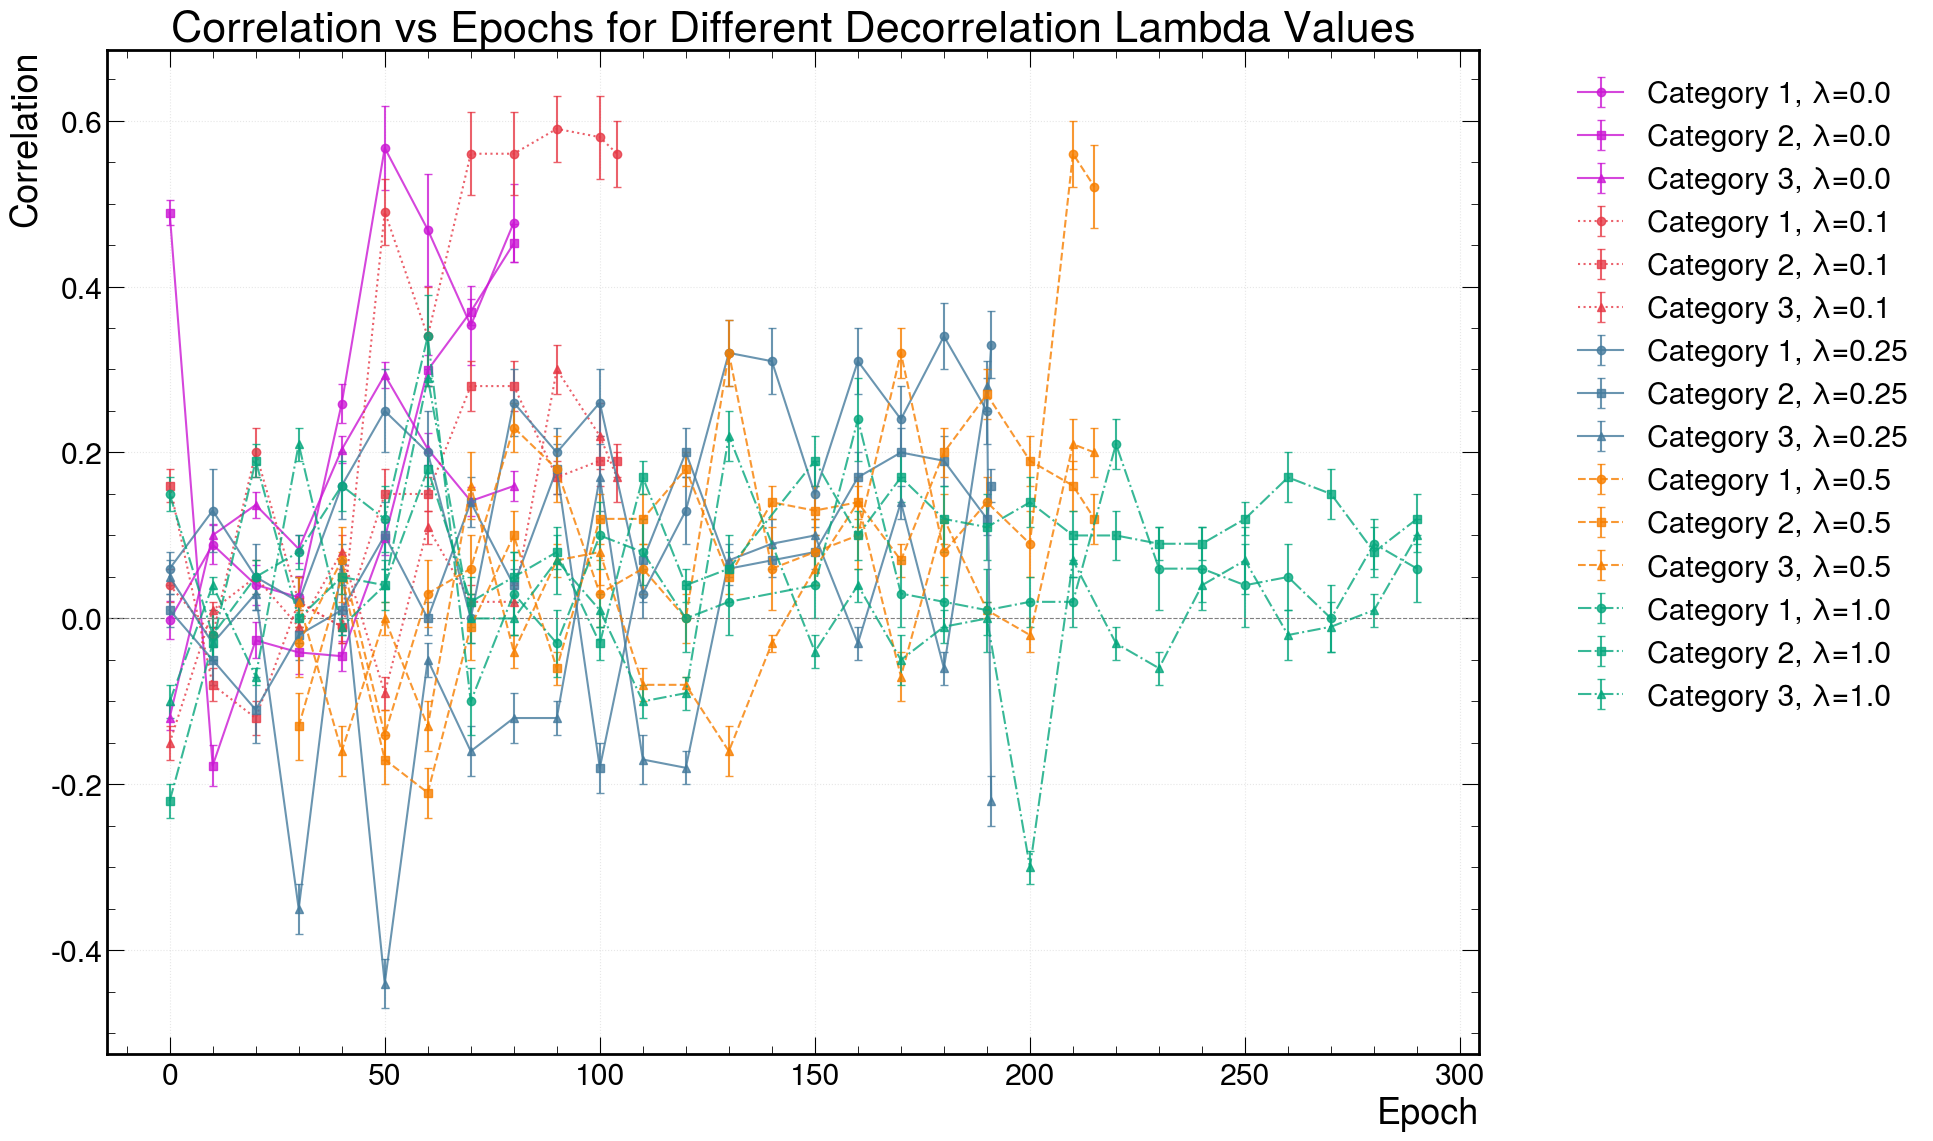

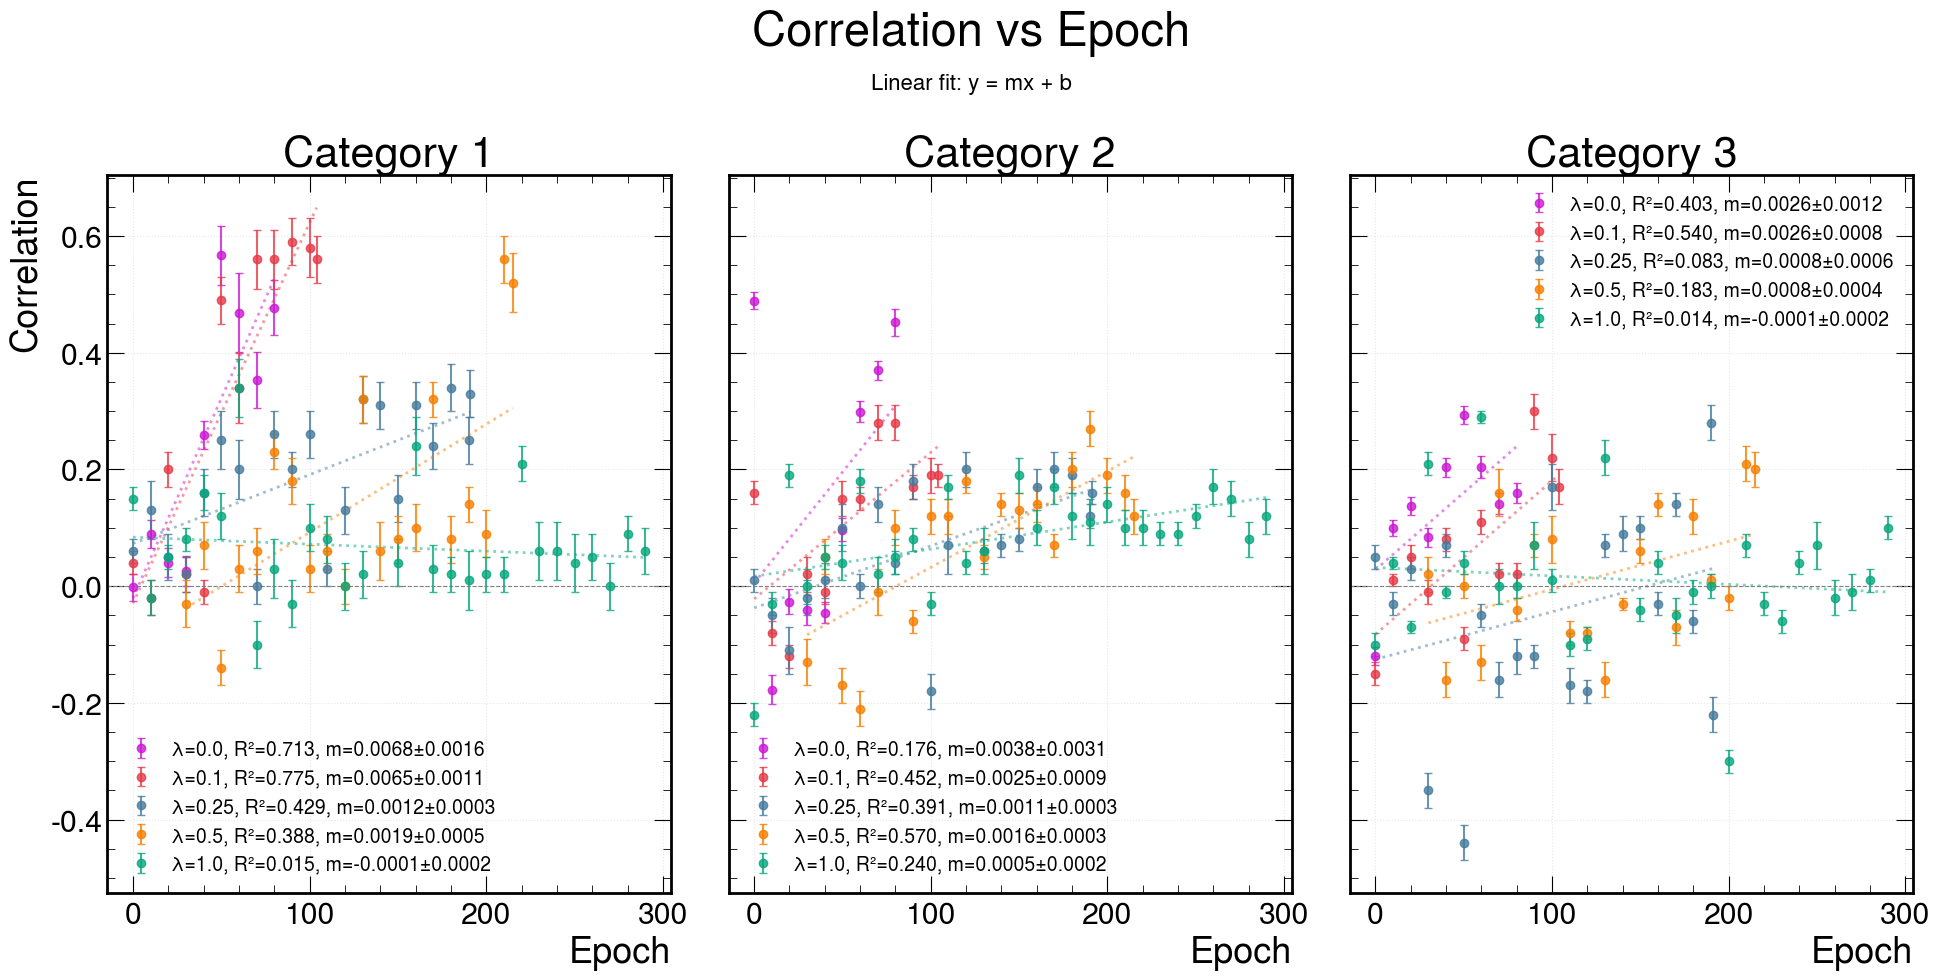

In [106]:
# Plotting code
fig, ax = plt.subplots(figsize=(20, 12))

colors = {0.00: "#CB18D4", 0.10: '#E63946', 0.25: '#457B9D', 0.50: '#F77F00', 1.00: '#06A77D'}
linestyles = {0.00: '-', 0.10: ':', 0.25: '-', 0.50: '--', 1.00: '-.'}
markers = {'cat1': 'o', 'cat2': 's', 'cat3': '^'}

# Plot for each decorr_lambda value
for decorr_lambda in colors.keys():
    df_subset = df[df['decorr_lambda'] == decorr_lambda].sort_values('epoch')
    
    for i, cat in enumerate(['cat1', 'cat2', 'cat3'], 1):
        ax.errorbar(
            df_subset['epoch'],
            df_subset[f'{cat}_corr'],
            yerr=df_subset[f'{cat}_corr_uncert'],
            label=f'Category {i}, λ={decorr_lambda}',
            fmt=markers[cat] + linestyles[decorr_lambda],
            color=colors[decorr_lambda],
            capsize=3,
            alpha=0.8,
            markersize=6
        )

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Correlation vs Epochs for Different Decorrelation Lambda Values')
ax.set_xlabel('Epoch')
ax.set_ylabel('Correlation')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================

CONNECT_DOTS = False

# Create three separate plots, one for each category
fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)

# Set overall figure title
fig.suptitle('Correlation vs Epoch', fontsize=34, y=1.00)

# Add textbox at the top of the figure
fig.text(0.5, 0.92, 'Linear fit: y = mx + b', 
         ha='center', fontsize=16, 
         )

# Plot each category in a separate subplot
for cat_idx, cat in enumerate(['cat1', 'cat2', 'cat3'], 1):
    ax = axes[cat_idx - 1]
    
    # Plot for each decorr_lambda value
    for decorr_lambda in colors.keys():
        df_subset = df[df['decorr_lambda'] == decorr_lambda].sort_values('epoch')
        
        # Determine format string based on CONNECT_DOTS
        if CONNECT_DOTS:
            fmt_string = 'o-'
        else:
            fmt_string = 'o'
        
        # Calculate R^2 for trendline
        x = df_subset['epoch'].astype(float)
        y = df_subset[f'{cat}_corr']
        
        # Fit linear model y = mx + b
        slope, intercept = np.polyfit(x, y, 1)
        
        # Calculate R^2
        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Calculate uncertainty in slope
        n = len(x)
        residuals = y - y_pred
        s_residual = np.sqrt(np.sum(residuals**2) / (n - 2))
        s_x = np.sqrt(np.sum((x - np.mean(x))**2)) # standard deviation of x
        slope_uncertainty = s_residual / s_x
        
        # Plot data points with error bars, including R^2 and slope in label
        ax.errorbar(
            df_subset['epoch'],
            df_subset[f'{cat}_corr'],
            yerr=df_subset[f'{cat}_corr_uncert'],
            label=f'λ={decorr_lambda}, R²={r_squared:.3f}, m={slope:.4f}±{slope_uncertainty:.4f}',
            fmt=fmt_string,
            color=colors[decorr_lambda],
            linestyle=linestyles[decorr_lambda] if CONNECT_DOTS else 'none',
            capsize=3,
            alpha=0.8,
            markersize=6,
        )
        
        # Generate trendline
        x_trend = np.linspace(x.min(), x.max(), 100)
        y_trend = slope * x_trend + intercept
        
        # Plot trendline
        ax.plot(
            x_trend,
            y_trend,
            linestyle=':',
            color=colors[decorr_lambda],
            alpha=0.5,
            linewidth=2
        )
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'Category {cat_idx}')
    ax.set_xlabel('Epoch')
    if cat_idx == 1:
        ax.set_ylabel('Correlation')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


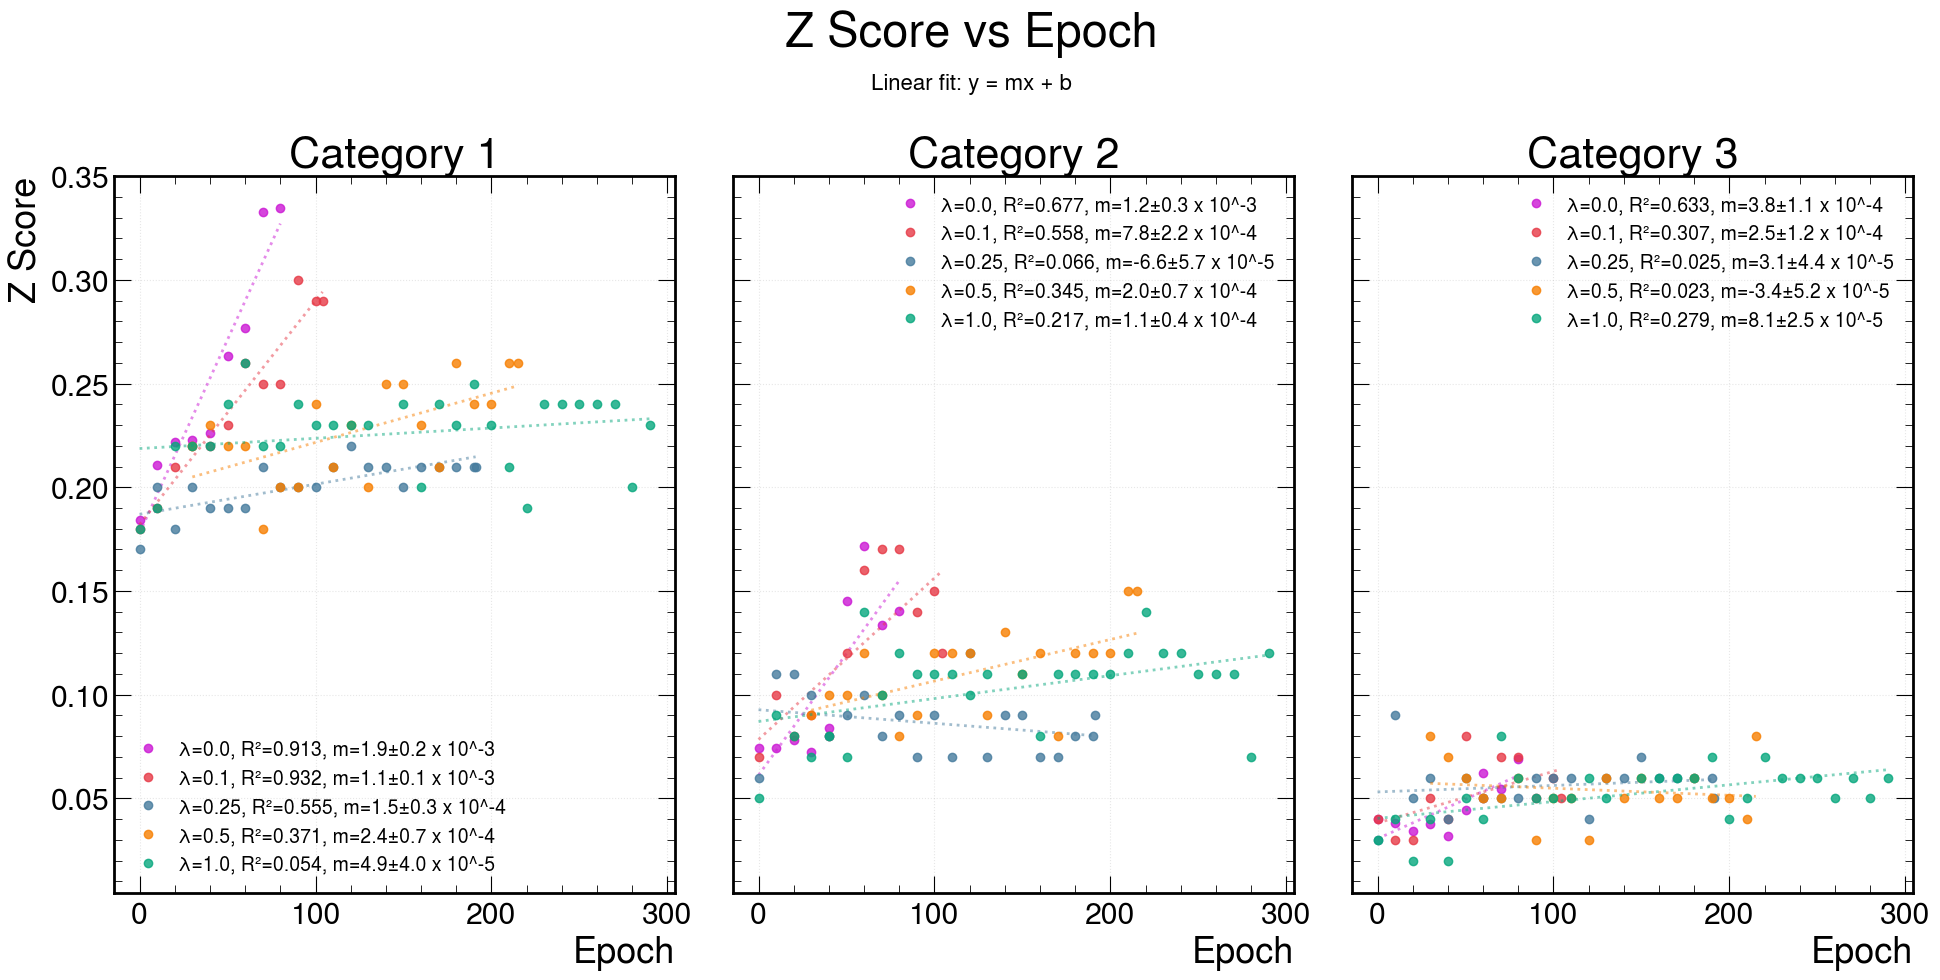

In [123]:
CONNECT_DOTS = False

# Create three separate plots for Z scores, one for each category
fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)

# Set overall figure title
fig.suptitle('Z Score vs Epoch', fontsize=34, y=1.00)

# Add textbox at the top of the figure
fig.text(0.5, 0.92, 'Linear fit: y = mx + b', 
         ha='center', fontsize=16)

# Plot each category in a separate subplot
for cat_idx, cat in enumerate(['cat1', 'cat2', 'cat3'], 1):
    ax = axes[cat_idx - 1]
    
    # Plot for each decorr_lambda value
    for decorr_lambda in [0.00, 0.10, 0.25, 0.50, 1.00]:
        df_subset = df[df['decorr_lambda'] == decorr_lambda].sort_values('epoch')
        
        if len(df_subset) == 0:
            continue
        
        # Determine format string based on CONNECT_DOTS
        if CONNECT_DOTS:
            fmt_string = 'o-'
        else:
            fmt_string = 'o'
        
        # Calculate R^2 for trendline
        x = pd.to_numeric(df_subset['epoch'], errors='coerce')
        y = df_subset[f'{cat}_Z']
        
        # Remove any NaN values
        mask = ~(x.isna() | y.isna())
        x = x[mask]
        y = y[mask]
        
        if len(x) < 2:
            continue
        
        # Fit linear model y = mx + b
        slope, intercept = np.polyfit(x, y, 1)
        
        # Calculate R^2
        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Calculate uncertainty in slope
        n = len(x)
        residuals = y - y_pred
        s_residual = np.sqrt(np.sum(residuals**2) / (n - 2))
        s_x = np.sqrt(np.sum((x - np.mean(x))**2))
        slope_uncertainty = s_residual / s_x
        
        # Slope nearest exponent for better readability
        exponent = np.floor(np.log10(abs(slope))) if slope != 0 else 0
        slope_arg = slope / (10**exponent)
        slope_uncertainty_arg = slope_uncertainty / (10**exponent)
        
        # Plot data points with R^2 and slope in label
        ax.plot(
            x,
            y,
            # label=f'λ={decorr_lambda}, R²={r_squared:.3f}, m={slope:.4f}±{slope_uncertainty:.4f}', # loses some small values
            # label=f'λ={decorr_lambda}, R²={r_squared:.3f}, m={slope:.2e}±{slope_uncertainty:.2e}', # messy
            label=f'λ={decorr_lambda}, R²={r_squared:.3f}, m={slope_arg:.1f}±{slope_uncertainty_arg:.1f} x 10^{int(exponent)}',
            marker='o',
            linestyle=linestyles[decorr_lambda] if CONNECT_DOTS else 'none',
            color=colors[decorr_lambda],
            alpha=0.8,
            markersize=6
        )
        
        # Generate trendline
        x_trend = np.linspace(x.min(), x.max(), 100)
        y_trend = slope * x_trend + intercept
        
        # Plot trendline
        ax.plot(
            x_trend,
            y_trend,
            linestyle=':',
            color=colors[decorr_lambda],
            alpha=0.5,
            linewidth=2
        )
    
    ax.set_title(f'Category {cat_idx}')
    ax.set_xlabel('Epoch')
    if cat_idx == 1:
        ax.set_ylabel('Z Score')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
CONNECT_DOTS = False

# Create three separate plots for Z scores, one for each category
fig, axes = plt.subplots(1, 1, figsize=(20, 10), sharey=True)

# Set overall figure title
fig.suptitle('Z Score vs Epoch', fontsize=34, y=1.00)

# Add textbox at the top of the figure
fig.text(0.5, 0.92, 'Linear fit: y = mx + b', 
         ha='center', fontsize=16)

# Plot each category in a separate subplot
ax = axes

# Plot for each decorr_lambda value
for decorr_lambda in [0.00, 0.10, 0.25, 0.50, 1.00]:
    df_subset = df[df['decorr_lambda'] == decorr_lambda].sort_values('epoch')
    
    if len(df_subset) == 0:
        continue
    
    # Determine format string based on CONNECT_DOTS
    if CONNECT_DOTS:
        fmt_string = 'o-'
    else:
        fmt_string = 'o'
    
    # Calculate R^2 for trendline
    x = pd.to_numeric(df_subset['epoch'], errors='coerce')
    y = df_subset[f'{cat}_Z']
    
    # Remove any NaN values
    mask = ~(x.isna() | y.isna())
    x = x[mask]
    y = y[mask]
    
    if len(x) < 2:
        continue
    
    # Fit linear model y = mx + b
    slope, intercept = np.polyfit(x, y, 1)
    
    # Calculate R^2
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Calculate uncertainty in slope
    n = len(x)
    residuals = y - y_pred
    s_residual = np.sqrt(np.sum(residuals**2) / (n - 2))
    s_x = np.sqrt(np.sum((x - np.mean(x))**2))
    slope_uncertainty = s_residual / s_x
    
    # Plot data points with R^2 and slope in label
    ax.plot(
        x,
        y,
        label=f'λ={decorr_lambda}, R²={r_squared:.3f}, m={slope:.4f}±{slope_uncertainty:.4f}',
        marker='o',
        linestyle=linestyles[decorr_lambda] if CONNECT_DOTS else 'none',
        color=colors[decorr_lambda],
        alpha=0.8,
        markersize=6
    )
    
    # Generate trendline
    x_trend = np.linspace(x.min(), x.max(), 100)
    y_trend = slope * x_trend + intercept
    
    # Plot trendline
    ax.plot(
        x_trend,
        y_trend,
        linestyle=':',
        color=colors[decorr_lambda],
        alpha=0.5,
        linewidth=2
    )

ax.set_title(f'Category {cat_idx}')
ax.set_xlabel('Epoch')
if cat_idx == 1:
    ax.set_ylabel('Z Score')
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()